In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# =========================
# STRATEGY CONFIG
# =========================
SYMBOL = "^NSEI"          # NIFTY 50 (use RELIANCE.NS for stocks)
INTERVAL = "15m"
PERIOD = "60d"

ORB_START = "09:15"
ORB_END = "09:30"
LAST_ENTRY_TIME = "11:30"

TARGET_POINTS = 40       # Risk : Reward = 1 : 2
STOPLOSS_POINTS = 20

print("✅ Configuration Loaded")


✅ Configuration Loaded


In [4]:
df_15m = yf.download(
    tickers=SYMBOL,
    interval=INTERVAL,
    period=PERIOD,
    progress=False
)


YF.download() has changed argument auto_adjust default to True


In [8]:
# 🔧 FIX yfinance MultiIndex columns
if isinstance(df_15m.columns, pd.MultiIndex):
    df_15m.columns = df_15m.columns.get_level_values(0)


In [9]:
df_15m = df_15m.reset_index()

df_15m.rename(columns={
    "Datetime": "time",
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close": "close",
    "Volume": "volume"
}, inplace=True)

df_15m["time"] = pd.to_datetime(df_15m["time"])
df_15m = df_15m.set_index("time")

df_15m = df_15m.between_time("09:15", "15:30")
df_15m["date"] = df_15m.index.date

df_15m.head()


Price,close,high,low,open,volume,date
time,,,,,,
2025-09-30 09:15:00+00:00,24632.500000,24654.000000,24603.650391,24639.949219,0,2025-09-30
2025-09-30 09:30:00+00:00,24614.849609,24634.800781,24598.150391,24631.699219,0,2025-09-30
2025-09-30 09:45:00+00:00,24633.599609,24634.900391,24603.300781,24613.500000,0,2025-09-30
2025-10-01 09:15:00+00:00,24835.349609,24867.849609,24816.199219,24849.150391,0,2025-10-01
2025-10-01 09:30:00+00:00,24822.500000,24848.800781,24820.300781,24835.900391,0,2025-10-01


In [11]:
def backtest_orb(df, target, stoploss):
    trades = []

    for date, day in df.groupby("date"):

        opening = day.between_time(ORB_START, ORB_END)
        if len(opening) < 2:
            continue

        orb_high = float(opening["high"].max())
        orb_low = float(opening["low"].min())

        trade = None

        for time, row in day.iterrows():
            price = float(row["close"])   # 🔥 force scalar

            if time.time() > pd.to_datetime(LAST_ENTRY_TIME).time():
                break

            if trade is None:
                if price > orb_high:
                    trade = {
                        "date": date,
                        "side": "LONG",
                        "entry": price,
                        "entry_time": time,
                        "sl": price - stoploss,
                        "target": price + target
                    }

                elif price < orb_low:
                    trade = {
                        "date": date,
                        "side": "SHORT",
                        "entry": price,
                        "entry_time": time,
                        "sl": price + stoploss,
                        "target": price - target
                    }

            else:
                if trade["side"] == "LONG":
                    if price >= trade["target"] or price <= trade["sl"]:
                        trade["exit"] = price
                        trade["exit_time"] = time
                        trade["pnl"] = price - trade["entry"]
                        trades.append(trade)
                        break

                else:  # SHORT
                    if price <= trade["target"] or price >= trade["sl"]:
                        trade["exit"] = price
                        trade["exit_time"] = time
                        trade["pnl"] = trade["entry"] - price
                        trades.append(trade)
                        break

    return pd.DataFrame(trades)


In [12]:
trades = backtest_orb(
    df=df_15m,
    target=TARGET_POINTS,
    stoploss=STOPLOSS_POINTS
)

trades.head()


""


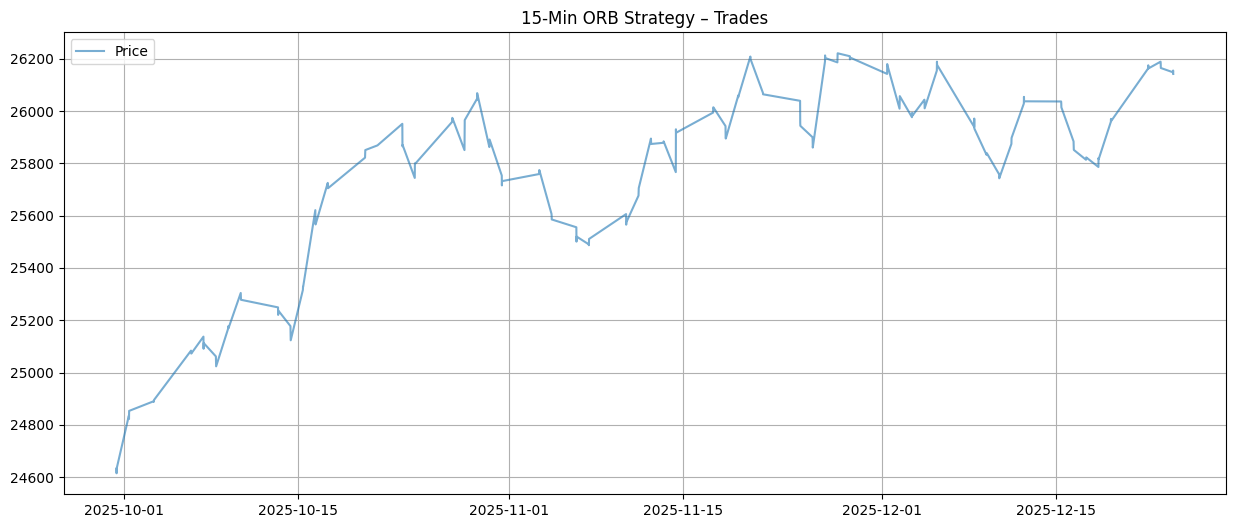

In [13]:
def plot_trades(df, trades):
    plt.figure(figsize=(15,6))
    plt.plot(df.index, df["close"], alpha=0.6, label="Price")

    for _, t in trades.iterrows():
        plt.scatter(t["entry_time"], t["entry"], color="green", marker="^", s=80)
        plt.scatter(t["exit_time"], t["exit"], color="red", marker="v", s=80)

    plt.title("15-Min ORB Strategy – Trades")
    plt.legend()
    plt.grid()
    plt.show()

plot_trades(df_15m, trades)


In [14]:
def plot_pnl(trades):
    plt.figure(figsize=(10,4))
    plt.bar(range(len(trades)), trades["pnl"])
    plt.axhline(0, color="black")
    plt.title("Trade-wise P&L")
    plt.xlabel("Trade #")
    plt.ylabel("PnL")
    plt.show()

plot_pnl(trades)


KeyError: 'pnl'

<Figure size 1000x400 with 0 Axes>

In [15]:
def performance(trades):
    print("Total Trades :", len(trades))
    print("Win Rate     :", round((trades.pnl > 0).mean()*100, 2), "%")
    print("Total PnL    :", round(trades.pnl.sum(), 2))
    print("Avg Trade    :", round(trades.pnl.mean(), 2))
    print("Max Gain     :", round(trades.pnl.max(), 2))
    print("Max Loss     :", round(trades.pnl.min(), 2))

performance(trades)


Total Trades : 0


AttributeError: 'DataFrame' object has no attribute 'pnl'